In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('train.csv')

In [3]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Column Types:**  
**Numerical -** `PassengerID`, `Age`, `Fare`  
**Categorical -** `Survived`, `Pclass`, `Sex`, `SibSp`, `Parch`, `Embarked`  
**Mixed -** `Name`, `Ticket`, `Cabin`

## Univariate Analysis

#### Numerical columns 

`PassengerId`

- it is not useful column 

`Age`

- Age is normally(almost) distributed
- 20% of the values are missing 
- There are some outliers

In [4]:
#Age
df['Age'].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

In [5]:
df['Age'].info()

<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Age
Non-Null Count  Dtype  
--------------  -----  
714 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


<Axes: xlabel='Age', ylabel='Count'>

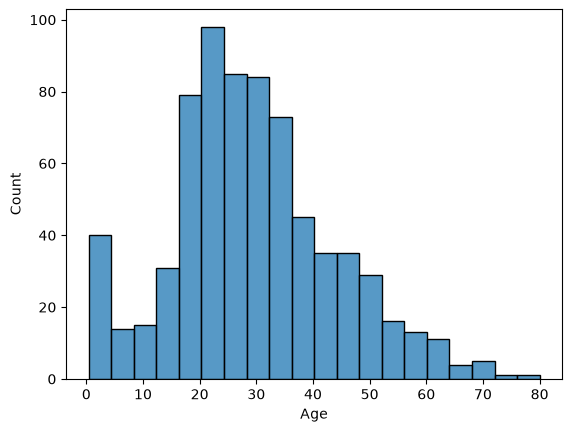

In [6]:
sns.histplot(data=df, x='Age')

<Axes: xlabel='Age', ylabel='Density'>

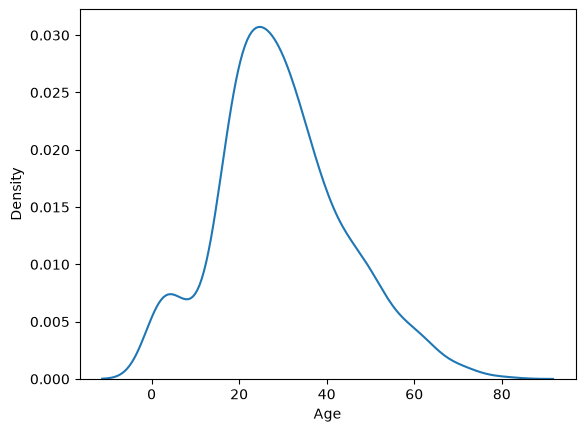

In [7]:
sns.kdeplot(data=df,x='Age')

In [8]:
df['Age'].skew()

np.float64(0.38910778230082704)

<Axes: xlabel='Age'>

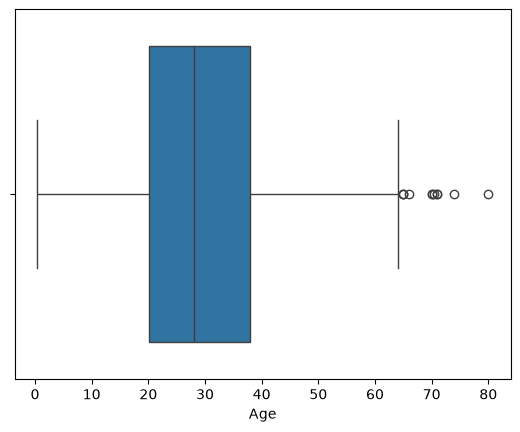

In [9]:
sns.boxplot(data= df,x='Age')

In [10]:
df[df['Age']>65]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
33,34,0,2,"Wheadon, Mr. Edward H",male,66.0,0,0,C.A. 24579,10.5000,NaN,S
96,97,0,1,"Goldschmidt, Mr. George B",male,71.0,0,0,PC 17754,34.6542,A5,C
116,117,0,3,"Connors, Mr. Patrick",male,70.5,0,0,370369,7.7500,NaN,Q
493,494,0,1,"Artagaveytia, Mr. Ramon",male,71.0,0,0,PC 17609,49.5042,NaN,C
630,631,1,1,"Barkworth, Mr. Algernon Henry Wilson",male,80.0,0,0,27042,30.0000,A23,S
672,673,0,2,"Mitchell, Mr. Henry Michael",male,70.0,0,0,C.A. 24580,10.5000,NaN,S
745,746,0,1,"Crosby, Capt. Edward Gifford",male,70.0,1,1,WE/P 5735,71.0000,B22,S
851,852,0,3,"Svensson, Mr. Johan",male,74.0,0,0,347060,7.7750,NaN,S


In [11]:
df['Age'].isnull().sum() / len(df['Age'])

np.float64(0.19865319865319866)

`Fare`

- The data is highly(positivily) Skewed 
- Fare coln actually contains the group and not indivisual fare(This might be and issue)
- we need to create a new coln called individual fare

In [12]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

In [13]:
df['Fare'].info()

<class 'pandas.Series'>
RangeIndex: 891 entries, 0 to 890
Series name: Fare
Non-Null Count  Dtype  
--------------  -----  
891 non-null    float64
dtypes: float64(1)
memory usage: 7.1 KB


<Axes: xlabel='Fare', ylabel='Count'>

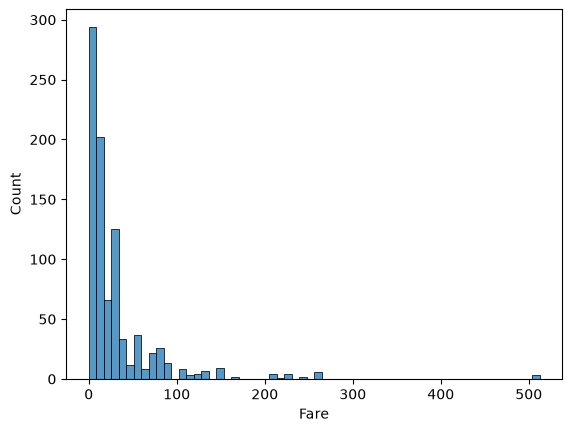

In [14]:
sns.histplot(data=df,x='Fare')

<Axes: xlabel='Fare', ylabel='Density'>

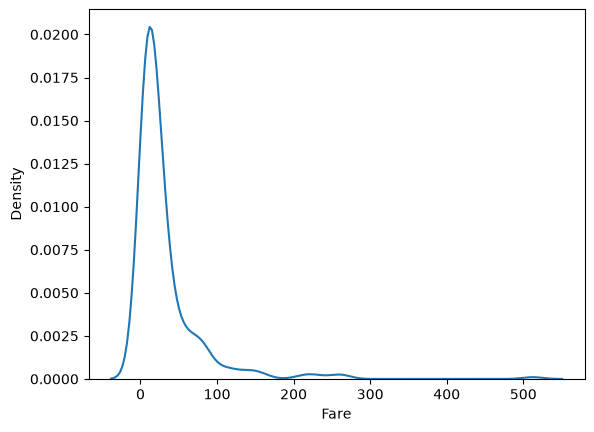

In [15]:
sns.kdeplot(data=df,x='Fare')

In [16]:
df['Fare'].skew()

np.float64(4.787316519674893)

<Axes: xlabel='Fare'>

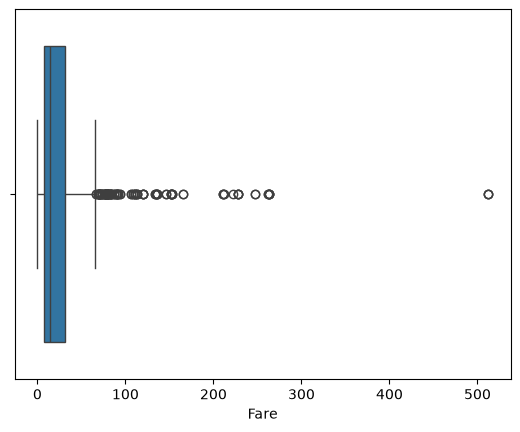

In [17]:
sns.boxplot(data=df,x='Fare')

In [18]:
df[df['Fare']>250]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,C23 C25 C27,S
88,89,1,1,"Fortune, Miss. Mabel Helen",female,23.0,3,2,19950,263.0000,C23 C25 C27,S
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
311,312,1,1,"Ryerson, Miss. Emily Borie",female,18.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C
341,342,1,1,"Fortune, Miss. Alice Elizabeth",female,24.0,3,2,19950,263.0000,C23 C25 C27,S
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,263.0000,C23 C25 C27,S
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
742,743,1,1,"Ryerson, Miss. Susan Parker ""Suzette""",female,21.0,2,2,PC 17608,262.3750,B57 B59 B63 B66,C


In [19]:
df['Fare'].isnull().sum()

np.int64(0)

## Categorical column

`Survived`

Conclusion
- o is Not Survived and 1 is Survived
- 60% died and 40% Survive
- in case not missing values

In [20]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

<Axes: xlabel='Survived', ylabel='count'>

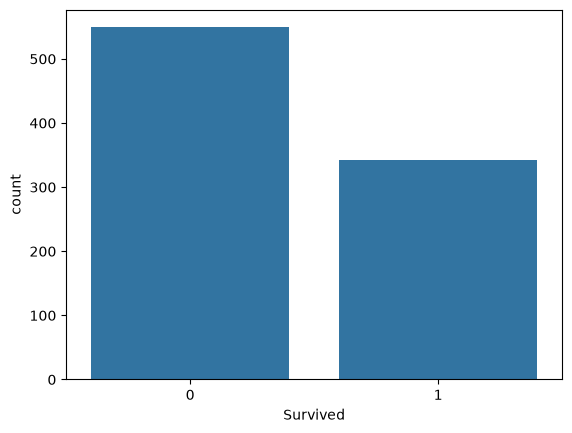

In [21]:
sns.countplot(data=df,x='Survived')

<Axes: >

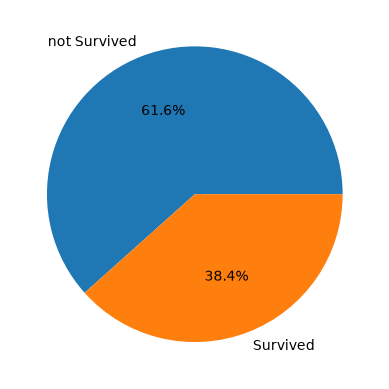

In [22]:
df['Survived'].value_counts().plot(kind='pie',autopct='%0.1f%%',labels=['not Survived','Survived'])

In [23]:
df['Survived'].isnull().sum()

np.int64(0)

`Pclass`

Conclusion
- 1 : 1st class , 2 : 2nd class and 3 : 3rd class 
- surprisingly less people travel in pclass 2 and more people  traveld in  pclass 1  

In [24]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

<Axes: xlabel='Pclass', ylabel='count'>

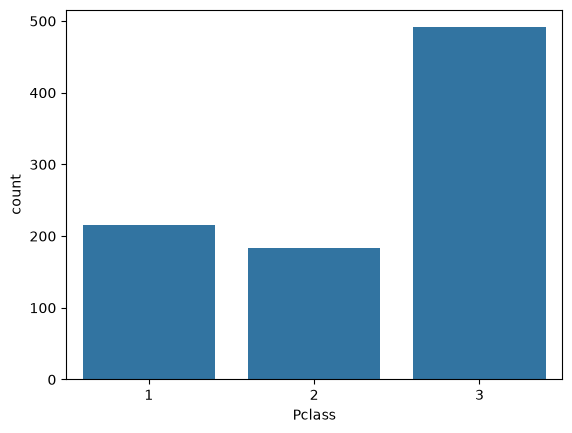

In [25]:
sns.countplot(data=df,x='Pclass')

<Axes: >

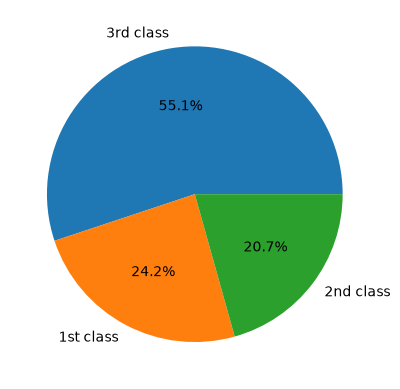

In [26]:
df['Pclass'].value_counts().plot(kind='pie',autopct='%0.1f%%',labels=['3rd class','1st class' ,'2nd class' ])

In [27]:
df['Pclass'].isnull().sum()

np.int64(0)

`Sex`

Coclusion 
- males are 64% and Femals are 35%

In [28]:
df['Sex'].value_counts()

Sex
male      577
female    314
Name: count, dtype: int64

<Axes: xlabel='Sex', ylabel='count'>

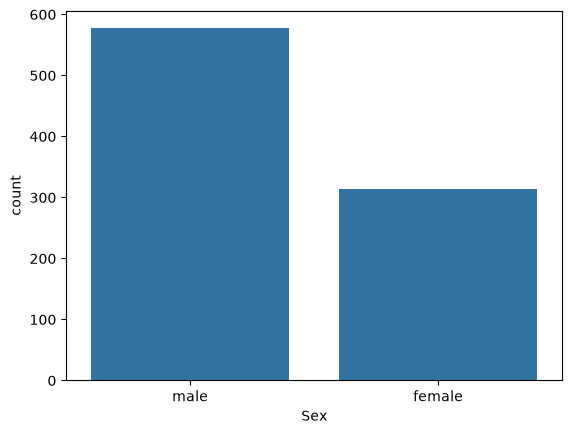

In [29]:
sns.countplot(data=df,x='Sex')

<Axes: >

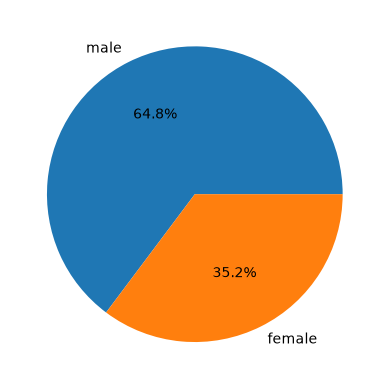

In [30]:
df['Sex'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [31]:
df['Sex'].isnull().sum()

np.int64(0)

`SibSp`

Coclusion
- Most passengers (68.24%) are travelling alone

In [32]:
df['SibSp'].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: xlabel='SibSp', ylabel='count'>

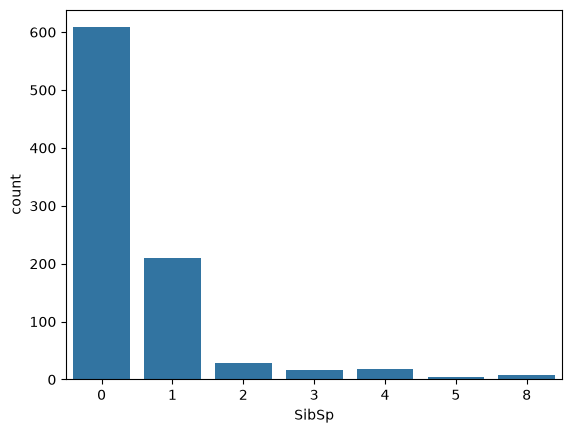

In [33]:
sns.countplot(data=df,x='SibSp')

<Axes: >

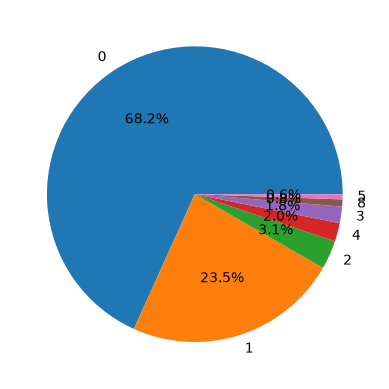

In [34]:
df['SibSp'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [35]:
df['SibSp'].isnull().sum()

np.int64(0)

`Parch`

Conclusion 
- 76%  people travel without siblings
- Create a new col called_alone

In [36]:
df['Parch'].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: xlabel='Parch', ylabel='count'>

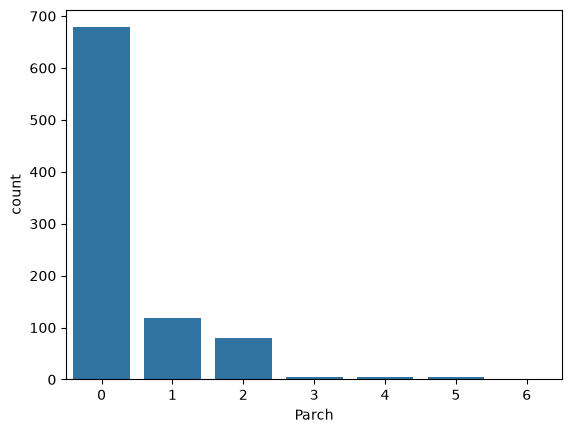

In [37]:
sns.countplot(data=df,x='Parch')

<Axes: >

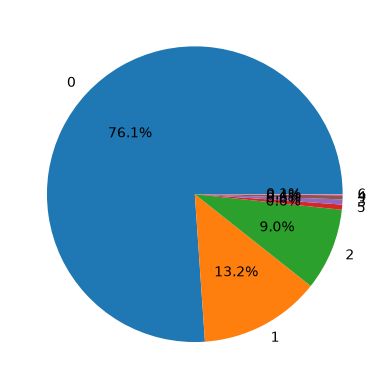

In [38]:
df['Parch'].value_counts().plot(kind='pie',autopct='%0.1f%%')

In [39]:
df['Parch'].isnull().sum()

np.int64(0)

`Embarked`

Conclusion 
- Jpurney of train ->S = Southampton station, C = Cherbourg station, Q = Queenstown station 
- 2 null values

In [40]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Station names = S = Southampton , C = Cherbourg, Q = Queenstown, 

<Axes: xlabel='Embarked', ylabel='count'>

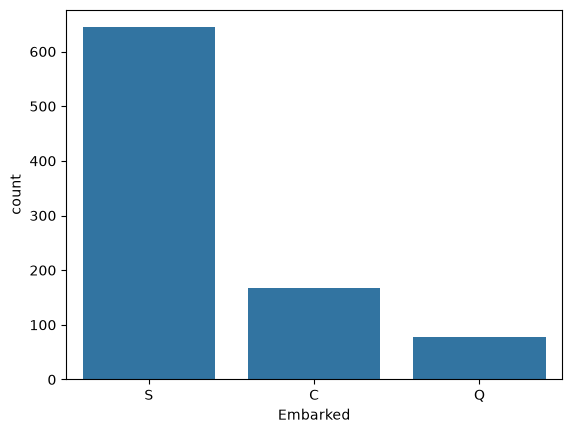

In [41]:
sns.countplot(data=df,x='Embarked')

<Axes: >

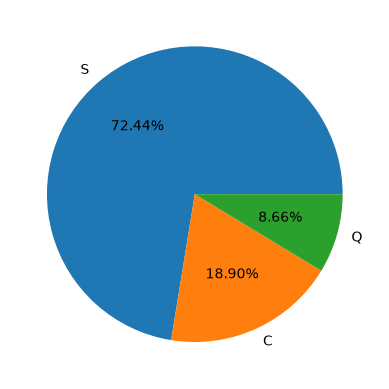

In [42]:
df['Embarked'].value_counts().plot(kind='pie',autopct='%0.2f%%')

In [43]:
df['Embarked'].isnull().sum()

np.int64(2)

## Mixed columns

`Name`

Conclusion 
- It contain the many features. 'Name, surname, title'
- If the women is married the in () braces her before marriage name.

In [44]:
df['Name'].value_counts()

Name
Braund, Mr. Owen Harris                                1
Cumings, Mrs. John Bradley (Florence Briggs Thayer)    1
Heikkinen, Miss. Laina                                 1
Futrelle, Mrs. Jacques Heath (Lily May Peel)           1
Allen, Mr. William Henry                               1
                                                      ..
Montvila, Rev. Juozas                                  1
Graham, Miss. Margaret Edith                           1
Johnston, Miss. Catherine Helen "Carrie"               1
Behr, Mr. Karl Howell                                  1
Dooley, Mr. Patrick                                    1
Name: count, Length: 891, dtype: int64

In [45]:
df['Name'].isnull().sum()

np.int64(0)

In [46]:
df['Name'].sample(10)

477                            Braund, Mr. Lewis Richard
382                                   Tikkanen, Mr. Juho
103                           Johansson, Mr. Gustaf Joel
750                                    Wells, Miss. Joan
499                                   Svensson, Mr. Olof
196                                  Mernagh, Mr. Robert
581    Thayer, Mrs. John Borland (Marian Longstreth M...
564                       Meanwell, Miss. (Marion Ogden)
324                             Sage, Mr. George John Jr
449                       Peuchen, Major. Arthur Godfrey
Name: Name, dtype: str

`Ticket`

Conclusion 
- In that two types of ticket one is fhully numeric and one is alphanumeric


In [47]:
df['Ticket'].sample(10)

631        347743
99         244367
44         330958
55          19947
549    C.A. 33112
846      CA. 2343
125          2651
383        113789
879         11767
727         36866
Name: Ticket, dtype: str

In [48]:
df['Ticket'].isnull().sum()

np.int64(0)

`Cabin`

Conclusion
-  There are 77% values are missing 
- Sometimes only alphabetic

In [49]:
df['Cabin'].sample(10)

828      NaN
858      NaN
860      NaN
375      NaN
373      NaN
611      NaN
358      NaN
128    F E69
846      NaN
476      NaN
Name: Cabin, dtype: str

In [50]:
df['Cabin'].isnull().sum()

np.int64(687)

In [51]:
(df['Cabin'].isnull().sum()/df['Cabin'].shape)*100

array([77.1043771])

## Bivariate analysis

select main important column  
There are two main columns `Survived` and `Age`

 Types of relationships 
- Numerical - Numerical
- Numerical - Categorical
- Categorical - Categorical

In [52]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


`Survived`

Conclusion
- `Survied` with `Pclass` =  Pclass 3 had the (75%) percentage of deaths And Pclass 1 is the safest class because it had the (37%) percentage of deaths
- `Survied` with `Sex` = Females had a higher survival rate (74.2%) than males (18.9%).
- `Survied` with `Embarked` = Passengers from C had the highest survival rate, followed by Q and S.
- `Survied` with `Age` = Passengers aged 0–5 years had a 70.45% survival rate, so we can say that younger passengers had a higher chance of survival.
- `Survied` with `Family` = Passengers with small families had a higher chance of survival.

In [53]:
pd.crosstab(df['Survived'],df['Pclass'],normalize='columns')

Pclass,1,2,3
Survived,,,
0,0.37037,0.527174,0.757637
1,0.62963,0.472826,0.242363


<Axes: xlabel='Pclass', ylabel='Survived'>

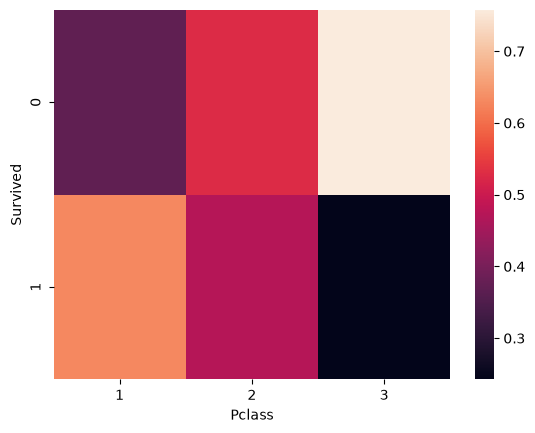

In [54]:
sns.heatmap(pd.crosstab(df['Survived'],df['Pclass'],normalize='columns'))

In [55]:
pd.crosstab(df['Survived'],df['Sex'],normalize='columns')*100

Sex,female,male
Survived,,
0,25.796178,81.109185
1,74.203822,18.890815


In [56]:
pd.crosstab(df['Survived'],df['Embarked'],normalize='columns')*100

Embarked,C,Q,S
Survived,,,
0,44.642857,61.038961,66.304348
1,55.357143,38.961039,33.695652


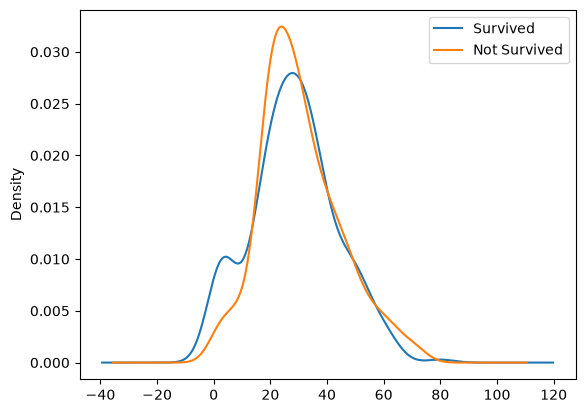

In [57]:
# Survived and age 
df[df['Survived']==1]['Age'].plot(kind='kde',label='Survived')
df[df['Survived']==0]['Age'].plot(kind='kde',label='Not Survived')

plt.legend()
plt.show()

In [58]:
df[(df['Age']>=0) & (df['Age']<= 5)]['Survived'].value_counts()

Survived
1    31
0    13
Name: count, dtype: int64

In [59]:
31/(31+13)*100

70.45454545454545

### Features Engineering 

In [60]:
df[df['SibSp']==8]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [61]:
df[df['Ticket']=='CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [62]:
df[df['Name'].str.contains('Sage')]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
641,642,1,1,"Sagesser, Mlle. Emma",female,24.0,0,0,PC 17477,69.30,B35,C
792,793,0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S


In [63]:
df1=pd.read_csv('test.csv')
df1

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [64]:
# concat train and test datasets
df = pd.concat([df,df1])

In [65]:
df[df['Ticket']=='CA. 2343']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
159,160,0.0,3,"Sage, Master. Thomas Henry",male,NaN,8,2,CA. 2343,69.55,NaN,S
180,181,0.0,3,"Sage, Miss. Constance Gladys",female,NaN,8,2,CA. 2343,69.55,NaN,S
201,202,0.0,3,"Sage, Mr. Frederick",male,NaN,8,2,CA. 2343,69.55,NaN,S
324,325,0.0,3,"Sage, Mr. George John Jr",male,NaN,8,2,CA. 2343,69.55,NaN,S
792,793,0.0,3,"Sage, Miss. Stella Anna",female,NaN,8,2,CA. 2343,69.55,NaN,S
846,847,0.0,3,"Sage, Mr. Douglas Bullen",male,NaN,8,2,CA. 2343,69.55,NaN,S
863,864,0.0,3,"Sage, Miss. Dorothy Edith ""Dolly""",female,NaN,8,2,CA. 2343,69.55,NaN,S
188,1080,NaN,3,"Sage, Miss. Ada",female,NaN,8,2,CA. 2343,69.55,NaN,S
342,1234,NaN,3,"Sage, Mr. John George",male,NaN,1,9,CA. 2343,69.55,NaN,S
360,1252,NaN,3,"Sage, Master. William Henry",male,14.5,8,2,CA. 2343,69.55,NaN,S


### `indivisual_fare`

In [66]:
df['indivisual_fare'] = df['Fare']/(df['SibSp']+df['Parch']+1)

<Axes: >

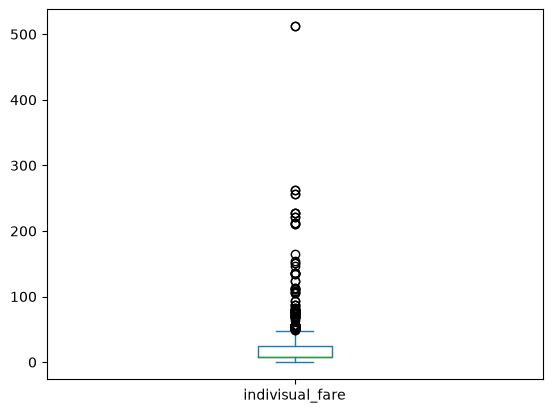

In [67]:
df['indivisual_fare'].plot(kind='box')

In [68]:
df['Family_size'] = df['SibSp'] + df['Parch'] + 1
df.sample(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,indivisual_fare,Family_size
149,150,0.0,2,"Byles, Rev. Thomas Roussel Davids",male,42.0,0,0,244310,13.0000,NaN,S,13.000000,1
175,176,0.0,3,"Klasen, Mr. Klas Albin",male,18.0,1,1,350404,7.8542,NaN,S,2.618067,3
416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1
102,103,0.0,1,"White, Mr. Richard Frasar",male,21.0,0,1,35281,77.2875,D26,S,38.643750,2
186,1078,NaN,2,"Phillips, Miss. Alice Frances Louisa",female,21.0,0,1,S.O./P.P. 2,21.0000,NaN,S,10.500000,2
38,930,NaN,3,"Sap, Mr. Julius",male,25.0,0,0,345768,9.5000,NaN,S,9.500000,1
241,1133,NaN,2,"Christy, Mrs. (Alice Frances)",female,45.0,0,2,237789,30.0000,NaN,S,10.000000,3
804,805,1.0,3,"Hedman, Mr. Oskar Arvid",male,27.0,0,0,347089,6.9750,NaN,S,6.975000,1
782,783,0.0,1,"Long, Mr. Milton Clyde",male,29.0,0,0,113501,30.0000,D6,S,30.000000,1
361,1253,NaN,2,"Mallet, Mrs. Albert (Antoinette Magnin)",female,24.0,1,1,S.C./PARIS 2079,37.0042,NaN,C,12.334733,3


In [69]:
df[['indivisual_fare','Fare']].describe()

,indivisual_fare,Fare
count,1308.000000,1308.000000
mean,20.518215,33.295479
std,35.774337,51.758668
min,0.000000,0.000000
25%,7.452767,7.895800
50%,8.512483,14.454200
75%,24.237500,31.275000
max,512.329200,512.329200


In [70]:
df = df.reset_index() 

In [71]:
pd.crosstab(df['Survived'], df['Family_size'], margins=True)

Family_size,1,2,3,4,5,6,7,8,11,All
Survived,,,,,,,,,,
0.0,374,72,43,8,12,19,8,6,7,549
1.0,163,89,59,21,3,3,4,0,0,342
All,537,161,102,29,15,22,12,6,7,891


In [72]:
# family_type
# 1-> alone 
# 2-4 -> small 
# >5 -> large

def transform_family_size(num):

    if num == 1:
        return 'alone'
    elif num>1 and num <5:
        return "small"
    else:
        return "large"

In [73]:
df['family_type'] = df['Family_size'].apply(transform_family_size)

In [74]:
df

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,indivisual_fare,Family_size,family_type
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2,small
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2,small
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1,alone
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2,small
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1,alone
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1,alone
1305,414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone
1306,415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1,alone
1307,416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1,alone


In [75]:
# Bivariate analysis
pd.crosstab(df['Survived'],df['family_type'],normalize='columns')*100

family_type,alone,large,small
Survived,,,
0.0,69.646182,83.870968,42.123288
1.0,30.353818,16.129032,57.876712


In [76]:
df['surname'] = df['Name'].str.split(',').str.get(0)
df['surname']

0              Braund
1             Cumings
2           Heikkinen
3            Futrelle
4               Allen
            ...      
1304          Spector
1305    Oliva y Ocana
1306          Saether
1307             Ware
1308            Peter
Name: surname, Length: 1309, dtype: object

In [77]:
df

,index,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,indivisual_fare,Family_size,family_type,surname
0,0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,3.625000,2,small,Braund
1,1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,35.641650,2,small,Cumings
2,2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,7.925000,1,alone,Heikkinen
3,3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,26.550000,2,small,Futrelle
4,4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,8.050000,1,alone,Allen
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,413,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S,8.050000,1,alone,Spector
1305,414,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C,108.900000,1,alone,Oliva y Ocana
1306,415,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S,7.250000,1,alone,Saether
1307,416,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S,8.050000,1,alone,Ware


### `title` From `Names` 

In [78]:
df['Title'] = df['Name'].str.split(',').str.get(1).str.strip().str.split(' ').str.get(0)

In [79]:
# Univariate analysis
df['Title'].value_counts()

Title
Mr.          757
Miss.        260
Mrs.         197
Master.       61
Rev.           8
Dr.            8
Col.           4
Ms.            2
Major.         2
Mlle.          2
Don.           1
Mme.           1
Lady.          1
Sir.           1
Capt.          1
the            1
Jonkheer.      1
Dona.          1
Name: count, dtype: int64

In [80]:
df['Title'].str.replace('Dr.','other')
df['Title'].str.replace('Col.','other')
df['Title'].str.replace('Major.','other')
df['Title'].str.replace('Don.','other')
df['Title'].str.replace('Capt.','other')
df['Title'].str.replace('the.','other')
df['Title'].str.replace('Jonkeer.','other')

0           Mr.
1          Mrs.
2         Miss.
3          Mrs.
4           Mr.
         ...   
1304        Mr.
1305      Dona.
1306        Mr.
1307        Mr.
1308    Master.
Name: Title, Length: 1309, dtype: object

In [81]:
temp_df = df[df['Title'].isin(['Mr.','Miss.','Mrs.','Master.','other'])]


In [82]:
pd.crosstab(temp_df['Survived'],temp_df['Title'],normalize='columns')*100

Title,Master.,Miss.,Mr.,Mrs.
Survived,,,,
0.0,42.5,30.21978,84.332689,20.8
1.0,57.5,69.78022,15.667311,79.2


### `Deck`
- assign the 'm' for missing 
- The cabin column contain the deck alphabet at the first index

In [83]:
df['Cabin'].isnull().sum()

np.int64(1014)

In [84]:
df['Cabin'].isnull().sum()/len(df['Cabin'])

np.float64(0.774637127578304)

In [85]:
df['Deck'] = df['Cabin'].str[0].fillna('m')

In [86]:
df['Deck'].value_counts()

Deck
m    1014
C      94
B      65
D      46
E      41
A      22
F      21
G       5
T       1
Name: count, dtype: int64

<Axes: xlabel='Deck'>

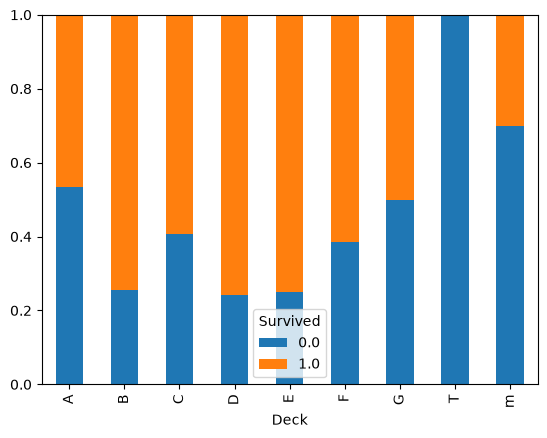

In [87]:
pd.crosstab(df['Deck'], df['Survived'], normalize='index').plot(kind='bar',stacked=True)